<div >
<img src = "../banner.jpg" />
</div>

<a target="_blank" href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_2026_20/blob/main/Lecture02/L02_01_FWL.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Frisch-Waugh-Lovell: fixed effects and what $\hat\beta$ is made of

FWL answers three different questions. This notebook covers two of them:

- **A. Computation** — absorbing high-dimensional fixed effects without ever building the dummy matrix.
- **B. Identification** — which variation in the data the coefficient is actually made of.

The third one (prediction: *leverage* and LOOCV) is left for the slides.

#  Bottlenecks in Everyday Data Analytics Tasks

*taken from Big Data Analytics by Ulrich Matter*

The objective is to broaden the perspective section focuses on the statistics perspective: compute something in a different way (with a different algorithm) but end up with essentially the same result. It is also an illustration of how diverse the already implemented solutions for working with large data in applied econometrics are, and how it makes sense to first look into more efficient algorithms/statistical procedures. 


## Efficient fixed effects estimation

Here we look into a very common computational problem in applied econometrics: estimation of a fixed effects model with various fixed-effects units (i.e., many intercepts). 

We aim to give an illustration of how a specific statistical procedure can help us reduce the computational burden substantially (here, by reducing the number of columns in the model matrix and therefore the burden of computing the inverse of a huge model matrix). 

As an example we will use the study called ["Friends in High Places"](https://www.aeaweb.org/articles?id=10.1257/pol.6.3.63) by Cohen and Malloy. They show that US Senators who are alumni of the same university/college tend to help each other out in votes on industrial policies if the corresponding policy is highly relevant for the state of one senator but not relevant for the state of the other senator. 


In [ ]:
#install.packages("pacman") #Run this line in Google Colab

In [ ]:
# Load the packages

require("pacman")

p_load("tidyverse","stargazer","data.table","lmtest","foreign","fixest","bacondecomp","panelView")


Loading required package: pacman


In [ ]:
# Data: replication files for Cohen & Malloy (2014), "Friends in High Places".
# They live zipped in the course datasets repo. We download and unzip them into
# the session, so the notebook runs the same way in Colab and on your machine.
# (the zip is ~20 MB; the uncompressed .dta is ~270 MB)

url_zip   <- "https://raw.githubusercontent.com/ignaciomsarmiento/datasets/main/114873-V1.zip"
data_dir  <- tempdir()
zip_local <- file.path(data_dir, "114873-V1.zip")
dta_local <- file.path(data_dir, "data_for_tables", "data_for_tables.dta")

if (!file.exists(dta_local)) {
  options(timeout = 600)
  download.file(url_zip, zip_local, mode = "wb")
  unzip(zip_local, files = "data_for_tables/data_for_tables.dta", exdir = data_dir)
}

# import data
cm <- as.data.table(read.dta(dta_local))

# keep only clean obs
cm <- cm[!(is.na(yes)
           |is.na(pctsumyessameparty)
           |is.na(pctsumyessameschool)
           |is.na(pctsumyessamestate))]

dim(cm)


[1] 425653    256


As an example we will replicate parts of Table 3 of the main article (p. 73). Specifically, we will estimate specifications (1) and (2). 

In both specifications, the dependent variable is an indicator `yes` that is equal to 1 if the corresponding senator voted Yes on the given bill and 0 otherwise. 

The main explanatory variables of interest are:

   - `pctsumyessameschool` (the percentage of senators from the same school as the corresponding senator who voted Yes on the given bill), 
   - `pctsumyessamestate` (the percentage of senators from the same state as the corresponding senator who voted Yes on the given bill), and 
   - `pctsumyessameparty` (the percentage of senators from the same party as the corresponding senator who voted Yes on the given bill). 
     
     
Specification 1 accounts for congress (time) fixed effects and senator (individual) fixed effects, and specification 2 accounts for congress-session-vote fixed effects and senator fixed effects. 

First, let us look at a very simple example to highlight where the computational burden in the estimation of such specifications is coming from. 

In terms of the regression model 1, the fixed effect\index specification means that we introduce an indicator variable (an intercept) for $N-1$ senators and $M-1$ congresses. That is, the simple model matrix ($X$) without accounting for fixed effects has dimensions 

$$
425653\times 4
$$. 

In [ ]:
# pooled model (no FE)
model0 <-   yes ~ 
  pctsumyessameschool + 
  pctsumyessamestate + 
  pctsumyessameparty 

dim(model.matrix(model0, data=cm))

[1] 425653      4

In contrast, the model matrix of specification (1) is of dimensions 

$$ 
425653\times 221 
$$, 

and the model matrix of specification (2) even of 

$$
425653\times6929
$$.


In [ ]:
model1 <- 
  yes ~ pctsumyessameschool + 
        pctsumyessamestate + 
        pctsumyessameparty + 
        factor(congress) +
        factor(id) -1
mm1 <- model.matrix(model1, data=cm)
dim(mm1)

[1] 425653    168

Using OLS to estimate such a model thus involves the computation of a very large matrix inversion (because $\hat{\beta}_{OLS} = (\mathbf{X}^\intercal\mathbf{X})^{-1}\mathbf{X}^{\intercal}\mathbf{y}$). 

In addition, the model matrix for specification 2 is about 22GB, which might further slow down the computer due to a lack of physical memory or even crash the R session altogether.

In order to set a point of reference, we first estimate specification (1) with standard OLS.


In [ ]:
# fit specification (1)
runtime <- system.time(fit1 <- lm(data = cm, formula = model1))
coeftest(fit1)[2:4,]


,Estimate,Std. Error,t value,Pr(>|t|)
pctsumyessamestate,0.11860868,0.001085411,109.275390,0.00000000
pctsumyessameparty,0.92640204,0.001397477,662.910254,0.00000000
factor(congress)101,-0.01458354,0.006428673,-2.268515,0.02329834


In [ ]:
# median amount of time needed for estimation (in seconds)
runtime[3]

elapsed 
 13.015

As expected, this takes more time to compute. However, there is an alternative approach to estimating such models that substantially reduces the computational burden by "sweeping out the fixed effects dummies". In the simple case of only one fixed effect variable (e.g., only individual fixed effects), the trick is called "within transformation" or "demeaning" and is quite simple to implement. 

For each of the categories in the fixed effect variable, compute the mean of the covariate and subtract the mean from the covariate's value.

In [ ]:
# illustration of within transformation for the senator fixed effects
cm_within <- 
  with(cm, data.table(yes = yes - ave(yes, id),
                      pctsumyessameschool = pctsumyessameschool -
                        ave(pctsumyessameschool, id),
                      pctsumyessamestate = pctsumyessamestate -
                        ave(pctsumyessamestate, id),
                      pctsumyessameparty = pctsumyessameparty -
                        ave(pctsumyessameparty, id)
                      ))

# comparison of dummy fixed effects estimator and within estimator
dummy_time <- system.time(fit_dummy <- 
              lm(yes ~ pctsumyessameschool + 
                       pctsumyessamestate +
                       pctsumyessameparty + 
                       factor(id) -1, data = cm
                         ))
within_time <- system.time(fit_within <- 
                             lm(yes ~ pctsumyessameschool +
                                      pctsumyessamestate + 
                                      pctsumyessameparty -1, 
                                      data = cm_within))
# computation time comparison
as.numeric(within_time[3])/as.numeric(dummy_time[3])


[1] 0.005703112

In [ ]:
# comparison of estimates
coeftest(fit_dummy)[1:3,]
coeftest(fit_within)

,Estimate,Std. Error,t value,Pr(>|t|)
pctsumyessameschool,0.04424462,0.001351867,32.72852,1.204583e-234
pctsumyessamestate,0.11863874,0.001085427,109.30143,0.000000e+00
pctsumyessameparty,0.92615124,0.001397064,662.92687,0.000000e+00



t test of coefficients:

                     Estimate Std. Error t value  Pr(>|t|)    
pctsumyessameschool 0.0442446  0.0013516  32.734 < 2.2e-16 ***
pctsumyessamestate  0.1186387  0.0010852 109.322 < 2.2e-16 ***
pctsumyessameparty  0.9261512  0.0013968 663.048 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Unfortunately, we cannot simply apply the same procedure in a specification with several fixed effects variables. However, there are packages that  provide a generalization of the linear within-estimator to several fixed effects  variables. 

One of these  is implemented in the `fixest` package. With this package, we can easily estimate both fixed-effect specifications in order to replicate the original results by Cohen and Malloy.


In [ ]:
p_load("fixest")

# model and clustered SE specifications
model1 <- yes ~ pctsumyessameschool + 
                pctsumyessamestate + 
                pctsumyessameparty |congress+id
model2 <- yes ~ pctsumyessameschool + 
                pctsumyessamestate + 
                pctsumyessameparty |congress_session_votenumber+id

# estimation
fit1 <- feols(model1,vcov=~id, data=cm)
fit2 <- feols(model2,vcov=~id, data=cm)


Finally we can display the regression table.

In [ ]:
etable(fit1,fit2,digits=3)

,,fit1,fit2
,<chr>,<chr>,<chr>
1,Dependent Var.:,yes,yes
2,,,
3,pctsumyessameschool,0.045** (0.016),0.052** (0.016)
4,pctsumyessamestate,0.119*** (0.013),0.122*** (0.012)
5,pctsumyessameparty,0.926*** (0.022),0.945*** (0.024)
6,Fixed-Effects:,----------------,----------------
7,congress,Yes,No
8,id,Yes,Yes
9,congress_session_votenumber,No,Yes


<div >
<img src = "figs/table3_cohen_malloy.png" />
</div>



## FWL, numerically

The theorem says the coefficient from the long regression and the coefficient from
the regression on **residualized** variables are numerically identical. Not similar:
identical.

With $X_1$ = the senator dummies, the matrix $M_{X_1}$ never has to be built:
applying $M_{X_1}$ to a vector is just subtracting its senator-specific mean.

In [ ]:
# M_X1 applied to a vector, when X1 are the dummies for g
residualize <- function(v, g) v - ave(v, g)

cm_res <- cm[, .(
  yes                 = residualize(yes, id),
  pctsumyessameschool = residualize(pctsumyessameschool, id),
  pctsumyessamestate  = residualize(pctsumyessamestate, id),
  pctsumyessameparty  = residualize(pctsumyessameparty, id)
)]

# the SHORT regression, on residualized variables
fwl <- lm(yes ~ pctsumyessameschool + pctsumyessamestate + pctsumyessameparty - 1,
          data = cm_res)

# the LONG regression, with the fixed effects inside
long_reg <- feols(yes ~ pctsumyessameschool + pctsumyessamestate + pctsumyessameparty | id,
                  data = cm)

comparison <- cbind(FWL = coef(fwl), feols = coef(long_reg))
comparison


                    FWL        feols     
pctsumyessameschool 0.04424462 0.04424462
pctsumyessamestate  0.11863874 0.11863874
pctsumyessameparty  0.92615124 0.92615124

In [ ]:
# How identical is identical?
max(abs(comparison[, "FWL"] - comparison[, "feols"]))


[1] 5.521902e-13



## B. Identification: what is $\hat\beta$ made of?

FWL says that in a regression with fixed effects

$$
\hat\beta = \frac{\widehat{Cov}(y,\tilde D)}{\widehat{Var}(\tilde D)},
\qquad \tilde D = M_{X_1} D
$$

The weight each observation gets is not set by $D$, it is set by $\tilde D$: treatment
*after* unit and time have been partialled out.

Goodman-Bacon (2021) opens up that expression into a weighted average of $2\times2$
comparisons, with weights that come precisely from $\widehat{Var}(\tilde D)$ within
each sub-comparison:

$$
\hat\beta^{DD} = \sum_k s_k\,\hat\beta_k^{2\times2}
$$

To see this we need a staggered difference-in-differences design. We use the
*castle doctrine* data from Cheng & Hoekstra (2013), which ships with `bacondecomp`.

### What is the castle doctrine, and what does the paper do?

**The doctrine.** Under common law, someone facing a threat outside the home has a
*duty to retreat*: lethal force is legitimate only as a last resort, once there is no
safe way out. The old exception to that rule is the home — *"a man's house is his
castle"* — where no duty to retreat applies. That exception is the **castle doctrine**.

**The reform.** Between 2005 and 2010, more than twenty US states passed laws
expanding the castle doctrine well beyond the house (Florida was first, in 2005).
Depending on the state, these laws:

- removed the duty to retreat anywhere a person is lawfully present — the part usually
  called *stand your ground*;
- extended the "castle" to vehicles and workplaces;
- added a presumption of reasonable fear when someone unlawfully enters;
- granted civil and criminal immunity to those who use force lawfully.

In economic terms, the reform **lowers the expected cost of using lethal force** in a
confrontation.

**Why the sign is an empirical question.** Two predictions pull in opposite directions:

- *Deterrence*: if potential victims are more likely to defend themselves, committing a
  crime becomes more expensive → burglary, robbery and aggravated assault should fall.
- *Escalation*: if lethal force is legally cheaper, confrontations that used to end in
  a retreat now end in a shooting → homicides should rise.

Theory does not settle which effect dominates. That is exactly the kind of question you
take to the data.

**What the paper does.** Cheng & Hoekstra (2013),
[*"Does Strengthening Self-Defense Law Deter Crime or Escalate Violence? Evidence from
Expansions to Castle Doctrine"*](https://doi.org/10.3368/jhr.48.3.821), *Journal of
Human Resources* 48(3): 821–854. They build a **state × year panel** and estimate a
difference-in-differences with state and year fixed effects, exploiting the fact that
states adopted the law in **different years** (staggered adoption). Their answer:

- **no deterrent effect** — burglary, robbery and aggravated assault do not fall;
- **homicides rise by about 8%**, roughly 600 additional homicides per year across the
  adopting states;
- and this is not a reclassification artifact: it is not simply that killings once
  recorded as murders now get recorded as justifiable homicides.

**The data.** `castle` ships with `bacondecomp`: a state-year panel where
`l_homicide` is the log homicide rate and `post` equals 1 once the state's castle
doctrine law is in effect.

**Why it belongs in this notebook.** Staggered adoption is exactly the setting where
two-way fixed effects stops being "the" DiD estimate and quietly becomes a *weighted
average of many comparisons* — some of them ones you would never have chosen. FWL is
what lets us open that average up and look inside.

In [ ]:
data("castle", package = "bacondecomp")

# The usual TWFE: state and year fixed effects
twfe <- feols(l_homicide ~ post | state + year, data = castle)
coef(twfe)


post 
0.08181162

### Look at the treatment structure first

Before decomposing anything, plot who is treated and when. `panelView` draws one row
per state and one column per year, coloured by treatment status.

Loading required package: panelView

## See https://yiqingxu.org/packages/panelview/ for more info.
## Report bugs -> yiqingxu@stanford.edu.




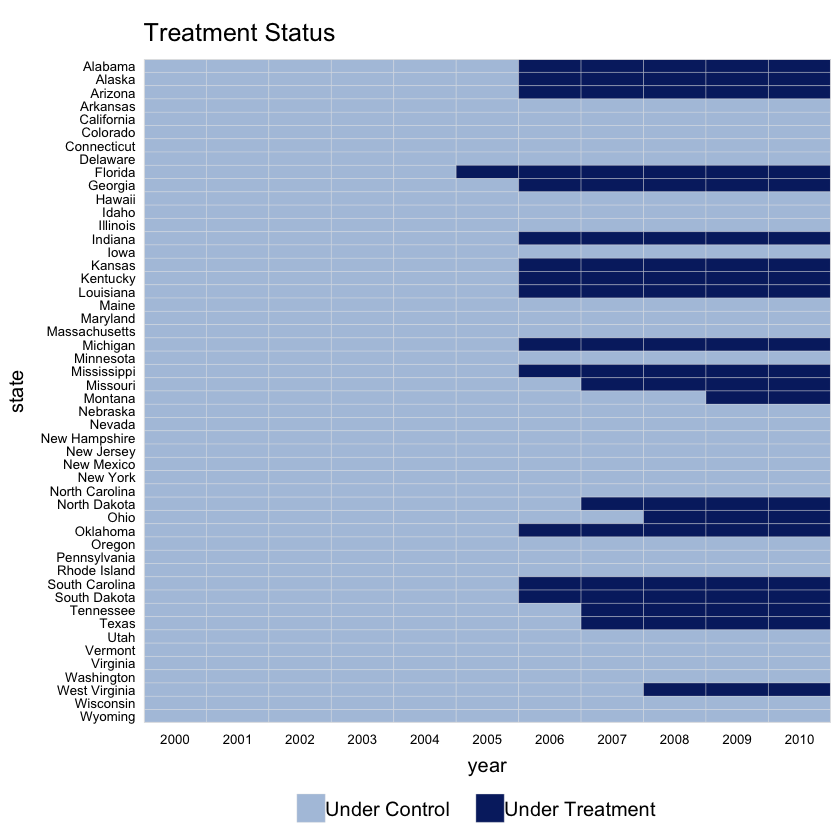

In [ ]:
# One row per state, one column per year, coloured by treatment status
panelview(l_homicide ~ post, data = castle, index = c("state", "year"), type = "treat")


Three things to read off this plot, and each one pays off below:

1. **Adoption is staggered.** States switch on in different years (2005–2010). There is
   no single "before" and "after" — which is precisely why TWFE has to average across
   many different comparisons.
2. **Treatment is absorbing.** Once a state turns on, it never turns off. No state
   repeals its castle doctrine law within the window.
3. **A large block of states never adopts.** These never-treated states are clean
   controls, available in every year.

That third fact is what drives the weights we are about to compute. Because
never-treated controls are plentiful here, the well-behaved `Treated vs Untreated`
comparison ends up carrying ~91% of the weight, and the pathological
`Later vs Earlier Treated` comparison — the one that uses already-treated units as
controls — only ~3%. In a design where *every* unit eventually gets treated, that block
of never-treated states disappears and the bad weight blows up.

In [ ]:
# The decomposition: every 2x2 comparison and its weight
bacon_dec <- bacon(l_homicide ~ post,
                   data = castle, id_var = "state", time_var = "year")

head(bacon_dec)


                      type  weight  avg_est
1 Earlier vs Later Treated 0.05976 -0.00554
2 Later vs Earlier Treated 0.03190  0.07032
3     Treated vs Untreated 0.90834  0.08796


,treated,untreated,estimate,weight,type
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3,2005,2006,-0.08312932,0.003404567,Earlier vs Later Treated
4,2007,2006,0.12596365,0.010894616,Later vs Earlier Treated
5,2009,2006,0.11209638,0.004085481,Later vs Earlier Treated
6,2008,2006,0.11069048,0.008170962,Later vs Earlier Treated
7,2006,99999,0.06823587,0.592394720,Treated vs Untreated
9,2005,99999,0.08016653,0.045568825,Treated vs Untreated


In [ ]:
# TWFE is exactly the weighted average of the 2x2 comparisons
weighted.mean(bacon_dec$estimate, bacon_dec$weight)


[1] 0.08181162

In [ ]:
# How much weight does each type of comparison carry?
bacon_dec %>%
  group_by(type) %>%
  summarise(total_weight = sum(weight), avg_estimate = weighted.mean(estimate, weight))


type,peso,estimador
<chr>,<dbl>,<dbl>
Earlier vs Later Treated,0.05976325,-0.005541979
Later vs Earlier Treated,0.03189818,0.070320634
Treated vs Untreated,0.90833857,0.087962491


`Later vs Earlier Treated` is the ugly comparison: it uses as controls units that
**were already treated**. Here it carries little weight (~3%) because there are many
never-treated states. In a design where every unit ends up treated there are no
never-treated units, and that weight blows up.

The number is not the point. The point is that **FWL lets you compute it**: it tells
you what variation your coefficient is made of, instead of leaving you to assume it.